In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Imports successful")

Imports successful


In [2]:
data = pd.read_csv("heart.csv")

print("First 5 rows:")
print(data.head())

print("\nDataset shape:", data.shape)

print("\nDataset information:")
data.info()

print("\nMissing values:")
print(data.isnull().sum())

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Dataset shape: (297, 14)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int6

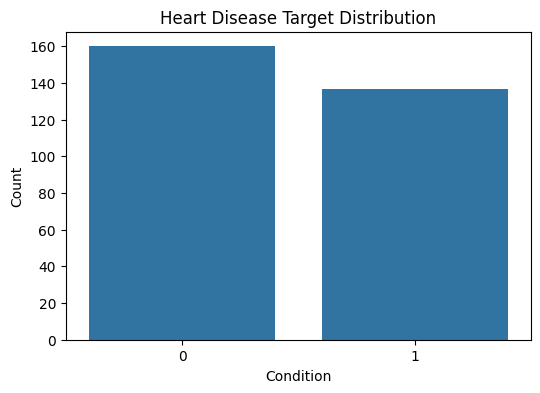

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x="condition", data=data)
plt.title("Heart Disease Target Distribution")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

In [4]:
features = ["age", "sex", "cp", "chol", "thalach"]
target = "condition"

X = data[features]
y = data[target]

print("Input shape:", X.shape)
print("Output shape:", y.shape)
print("Features:", features)

Input shape: (297, 5)
Output shape: (297,)
Features: ['age', 'sex', 'cp', 'chol', 'thalach']


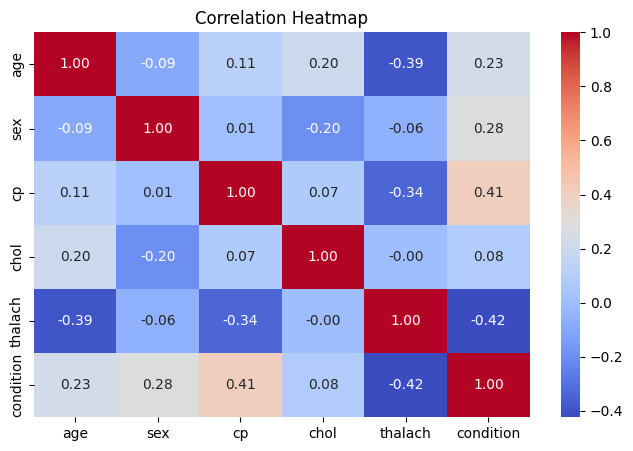

In [5]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    data[features + [target]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (237, 5)
Testing shape: (60, 5)


In [7]:
# Train the Random Forest Bagging model
bagging_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred = bagging_model.predict(X_test)

print("Random Forest Bagging model trained successfully.")

Random Forest Bagging model trained successfully.


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Bagging Accuracy:", accuracy)
print(f"Accuracy: {accuracy:.2%}")

Random Forest Bagging Accuracy: 0.7666666666666667
Accuracy: 76.67%


In [9]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        32
           1       0.73      0.79      0.76        28

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



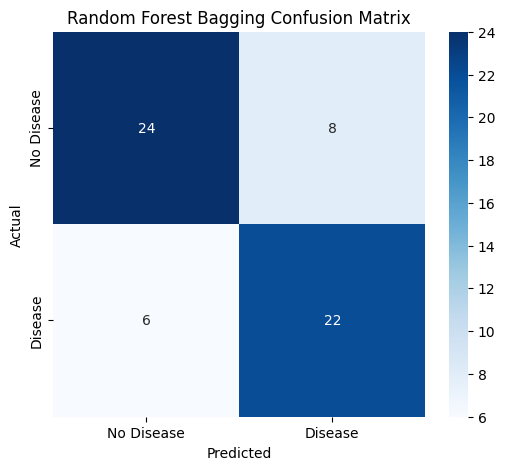

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Random Forest Bagging Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

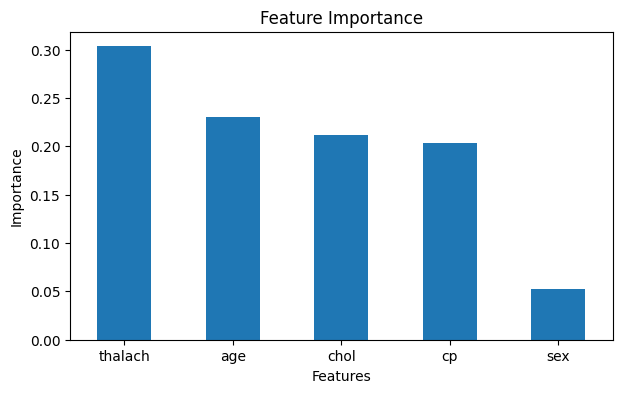

thalach    0.303246
age        0.229773
chol       0.211343
cp         0.203299
sex        0.052339
dtype: float64


In [11]:
importance = pd.Series(
    bagging_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=0)
plt.show()

print(importance)

In [12]:
# Verification checks
assert len(data) == 297
assert X.shape == (297, 5)
assert y.shape == (297,)
assert X_train.shape == (237, 5)
assert X_test.shape == (60, 5)
assert len(y_pred) == len(y_test)

print("All verification checks passed.")
print(f"Final test accuracy: {accuracy:.2%}")

All verification checks passed.
Final test accuracy: 76.67%


In [ ]:
with open("heart_disease_bagging.pkl", "wb") as file:
    pickle.dump(bagging_model, file)

print("Random Forest Bagging model saved successfully.")

In [13]:
# Final saved-model verification
with open("heart_disease_bagging.pkl", "rb") as file:
    saved_model = pickle.load(file)

saved_predictions = saved_model.predict(X_test)

assert np.array_equal(saved_predictions, y_pred)

print("Saved model loaded successfully.")
print(f"Saved model accuracy: {accuracy_score(y_test, saved_predictions):.2%}")
print("Model verification passed.")

Saved model loaded successfully.
Saved model accuracy: 76.67%
Model verification passed.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
